# LangGraph Components

## 1. State (❤️ Heart of LangGraph)

- Shared memory accessible by all nodes.
- Stores the application's current data.
- Nodes **read** from it and **return updates** to it.
- Defined using `TypedDict`, `dataclass`, or `Pydantic`.
**Flow**
```text
Input State → Node → Updated State → Next Node
```
---
## 2. Nodes
- A node is simply a Python function.
- Performs one specific task (LLM call, tool call, API call, etc.).
- Takes the current state as input.
- Returns a partial state update.

**Flow**
```text
State → Node(Function) → State Update
```
---
## 3. Edges
- Connect one node to another.
- Define the execution flow.
- Unconditional edges always go to the same next node.
**Flow**
```text
START → Search → LLM → END
```
---
## 4. Conditional Edges

- Decide the next node based on the current state.
- Similar to an `if-else` statement.
- Enable branching, retries, loops, and agent decision-making.
**Flow**
```text
           Search
              │
      documents found?
         ┌────┴────┐
        Yes       No
         │         │
        LLM    Search Again
         │         │
         └────┬────┘
              END
```
## 5. Reducers
- Define **how state updates are merged** when multiple nodes update the same key.
- By default, LangGraph **overwrites** the existing value.
- Reducers allow custom merge behavior (e.g., append, sum, merge).
- Commonly used for accumulating messages or list data.
**Without Reducer**
```text
["Hi"] → Update ["Hello"] → ["Hello"]
```
**With Reducer (Append)**
```text
["Hi"] → Update ["Hello"] → ["Hi", "Hello"]
```

## Build a basic chatbot with Langgraph(Graph API)

In [67]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END 
from langgraph.graph.message import add_messages # add_messages is a reducer

In [69]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

In [70]:
graph_builder

In [71]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [72]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")

In [73]:
 ## Node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]} 

In [74]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding edges 
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

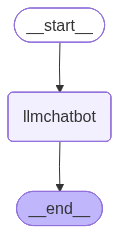

In [75]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png())) 
except Exception:
    pass
    

In [76]:
response=graph.invoke({"messages":"Hello"})

In [77]:
response["messages"][-1].content

'Hello. Is there something I can help you with or would you like to chat?'

In [78]:
for event in graph.stream({"messages":"Hi,How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here to help answer any questions or provide information you might need. How can I assist you today?


## CHATBOT WITH TOOL

In [79]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [80]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int
        
    Returns:
        int: output int
    """
    return a*b


In [81]:
tools=[tool,multiply]

In [82]:
llm_with_tool=llm.bind_tools(tools)

In [83]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x72b34161e390>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72b342cb7890>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimi

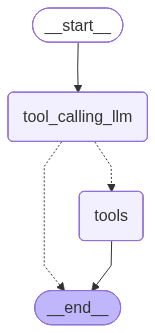

In [84]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest result from llm is a tool call ->tools condition routes to tools(node)
    # else: tools condition routes to END
    tools_condition
)

builder.add_edge("tools",END)

## Compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [85]:
result=graph.invoke({"messages":"What is the recent AI news?"})

In [87]:
result["messages"][-1].content

"{'error': ValueError('Error 400: When time_range is set, start_date or end_date cannot be set')}"

In [88]:
result=graph.invoke({"messages":"What is 2 multiplied by 3?"})
result["messages"][-1].content   ## here also tool call happening  

'6'

## Failure case : When a user request needs the usage of multiple tools calls,model calls one tool and exits with output

In [89]:
result=graph.invoke({"messages":"What is 2 multiplied by 3 and give one recent AI news?"})
result["messages"][-1].content 

'6'

In [90]:
result

{'messages': [HumanMessage(content='What is 2 multiplied by 3 and give one recent AI news?', additional_kwargs={}, response_metadata={}, id='2736b9fe-02dc-44b5-8b24-c863a50396f9'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jbatw3pnv', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 1760, 'total_tokens': 1799, 'completion_time': 0.073911188, 'completion_tokens_details': None, 'prompt_time': 0.129684712, 'prompt_tokens_details': None, 'queue_time': 0.058404877, 'total_time': 0.2035959}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f34d9-b59e-7431-a965-773b9177db47-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'jbatw3pnv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metad

 # ReAct Agent : Required for efficient communication between agents
 ![React Agent Architecture](assets/image1.png)
 - ACT
 - OBSERVE
 - REASON


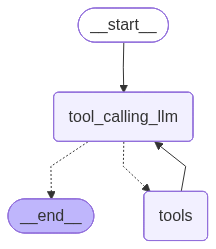

In [91]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest result from llm is a tool call ->tools condition routes to tools(node)
    # else: tools condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

## Compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [92]:
result=graph.invoke({"messages":"Give me recent AI news and then multiply 2 and 3"})
result["messages"][-1].content 

"The function 'multiply' returned the product of 2 and 3 as 6."

In [93]:
result

{'messages': [HumanMessage(content='Give me recent AI news and then multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='597ba80a-6eee-4fc8-afb3-602b868649df'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'f4eqscjpd', 'function': {'arguments': '{"query":"recent AI news","time_range":"week","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'yw1fzf0b5', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 1758, 'total_tokens': 1807, 'completion_time': 0.070268847, 'completion_tokens_details': None, 'prompt_time': 0.119211758, 'prompt_tokens_details': None, 'queue_time': 0.056194973, 'total_time': 0.189480605}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f34d9-f56e-7d63-9b3

# Adding Memory in Agentic Graph

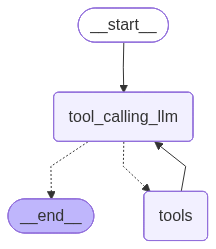

In [100]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edge
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest result from llm is a tool call ->tools condition routes to tools(node)
    # else: tools condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

## Compile the graph
graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [105]:
## We need to create a thread id for holding a session memory for a thread
from langchain_core.messages import HumanMessage
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":[HumanMessage(content="Hello, my name is Arun")]},config=config)
response

{'messages': [HumanMessage(content='Hello, my name is Arun', additional_kwargs={}, response_metadata={}, id='3f887310-faa1-46f7-9490-a9e97001f640'),
  AIMessage(content='Nice to meet you, Arun. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 1752, 'total_tokens': 1768, 'completion_time': 0.02065528, 'completion_tokens_details': None, 'prompt_time': 0.111286031, 'prompt_tokens_details': None, 'queue_time': 0.049156949, 'total_time': 0.131941311}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f34e1-e322-7d40-a58e-29591b129543-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 16, 'total_tokens': 1768})]}

In [106]:
response["messages"][-1].content

'Nice to meet you, Arun. How can I assist you today?'

In [107]:
response=graph.invoke({"messages":"Hey,do you remeber my name?"},config=config)
response

{'messages': [HumanMessage(content='Hello, my name is Arun', additional_kwargs={}, response_metadata={}, id='3f887310-faa1-46f7-9490-a9e97001f640'),
  AIMessage(content='Nice to meet you, Arun. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 1752, 'total_tokens': 1768, 'completion_time': 0.02065528, 'completion_tokens_details': None, 'prompt_time': 0.111286031, 'prompt_tokens_details': None, 'queue_time': 0.049156949, 'total_time': 0.131941311}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f34e1-e322-7d40-a58e-29591b129543-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 16, 'total_tokens': 1768}),
  HumanMessage(content='Hey,do you remeber my name?', additional_kwargs={}, response_metadata={}, id='0b73a365-667d-4ea